# Student Name: Zohain Javed
# Student ID: 40457802
## Section 3: Statistical analyses of feature data

In [2]:
# Setting up the required tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Loading the data
df = pd.read_csv('40457802_features.csv')

# Grouping the items (Living vs Non-Living)
living_labels = ['cherry', 'banana', 'lemon', 'tree']
living_df = df[df['label'].isin(living_labels)]
non_living_df = df[~df['label'].isin(living_labels)] # Rest of the labels are non-living

print("Data groups created successfully!")

Data groups created successfully!


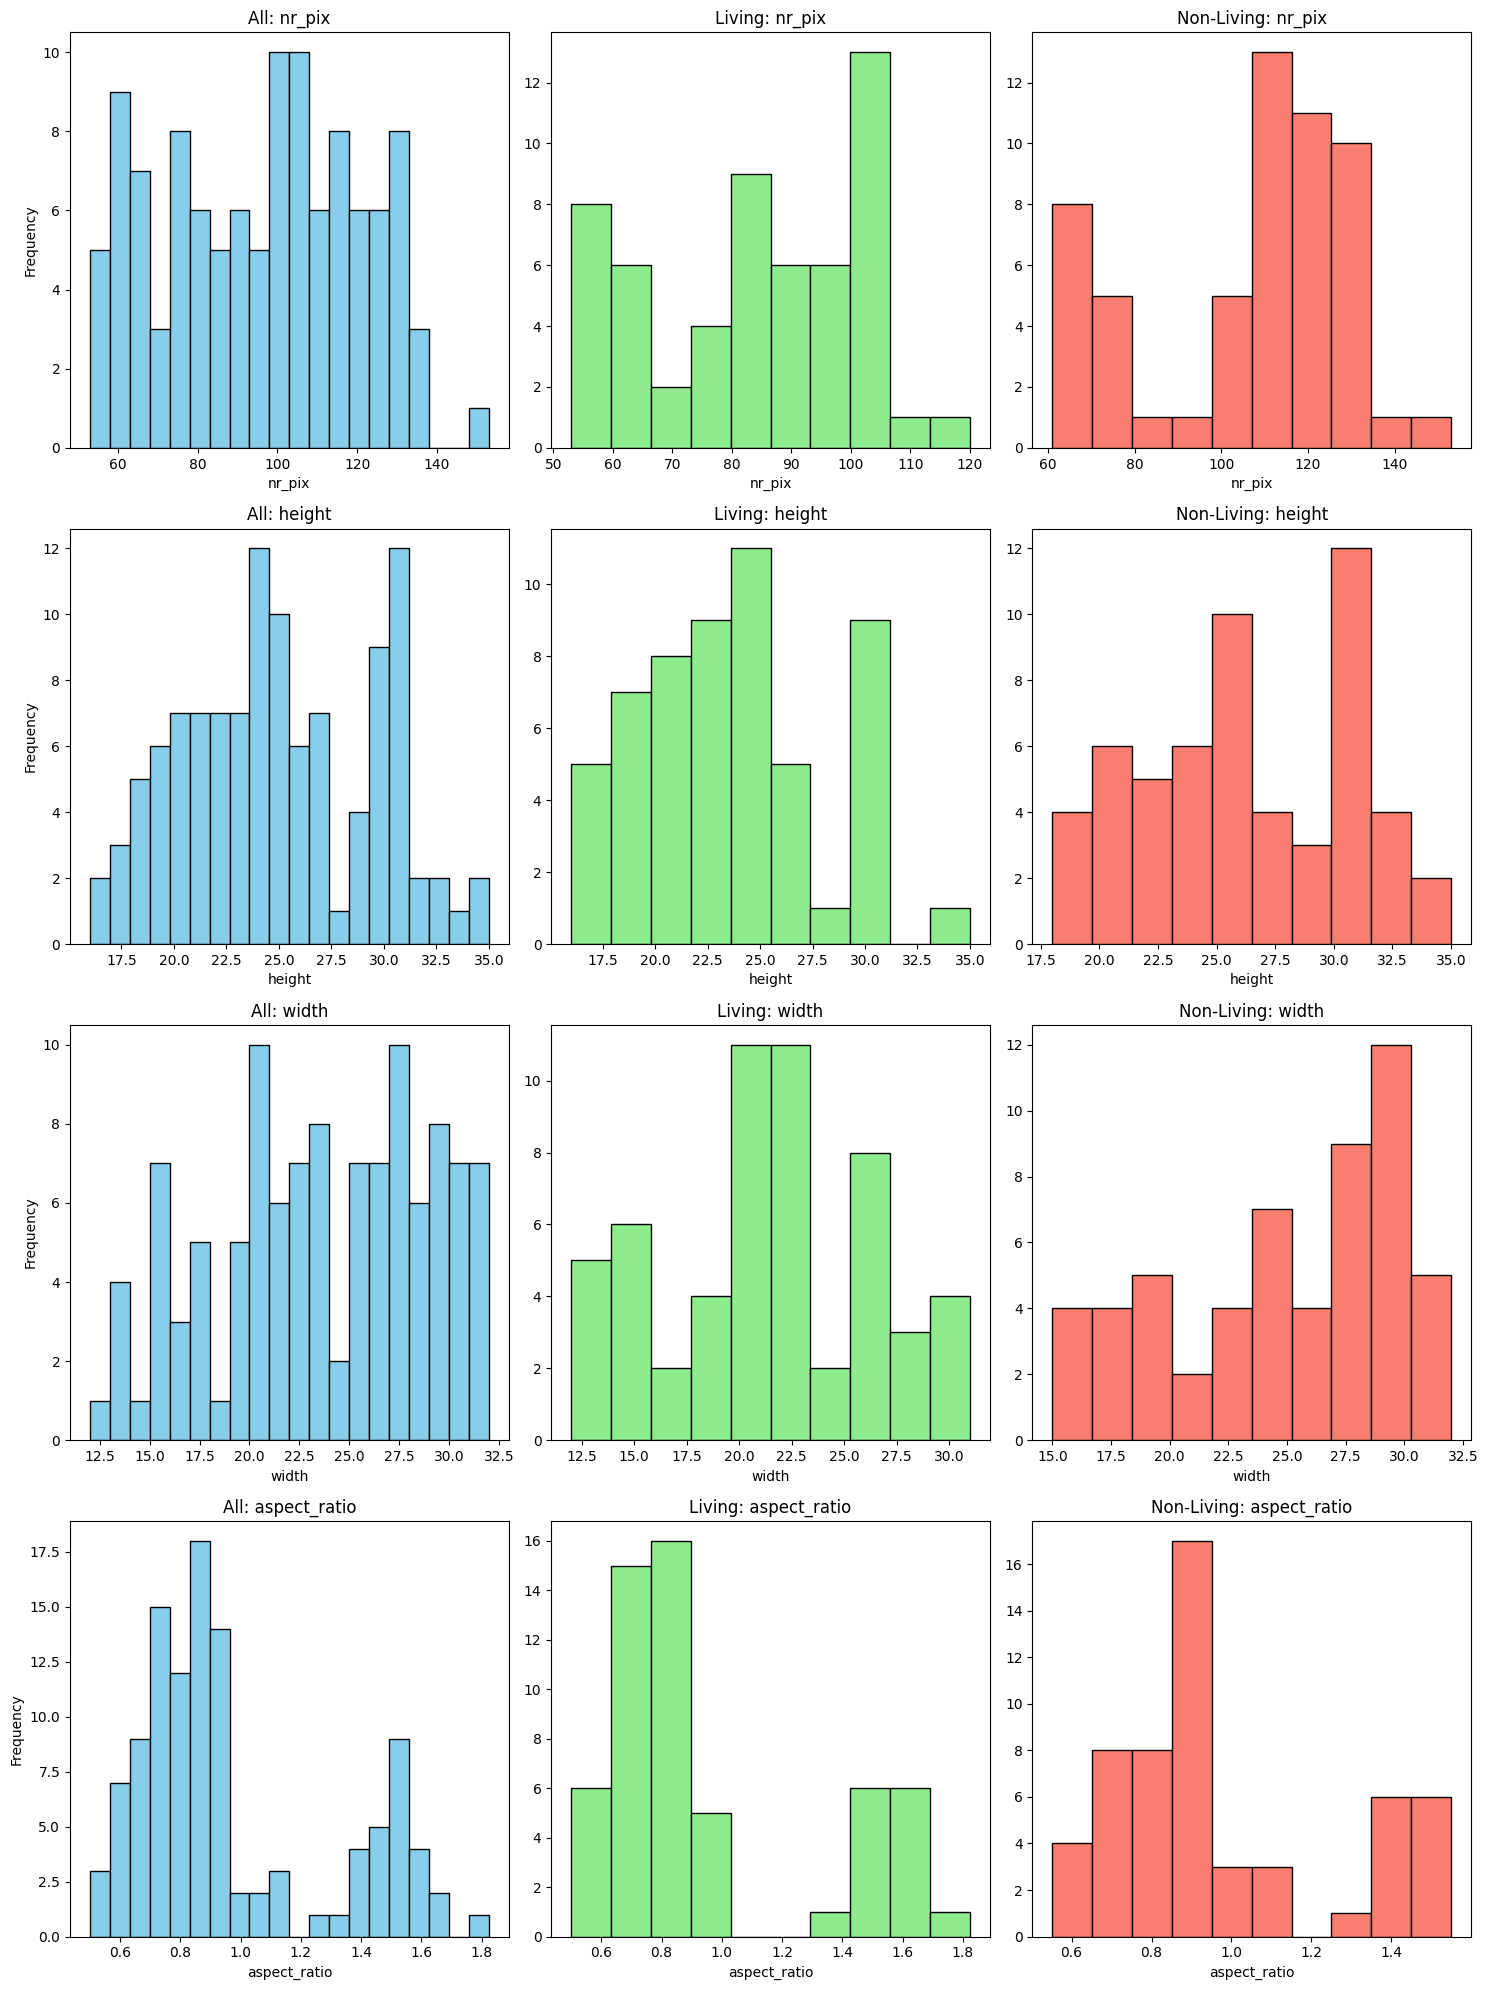

In [17]:
# Task 3.1: Histograms

features = ['nr_pix', 'height', 'width', 'aspect_ratio']

# Plotting 4 features across 3 categories (living, non-living, all)
# Creating a figure with 4 rows and 3 columns (12 histograms total)
# Row[0-3] = nr_pix, height, width, aspect_ratio
# Col[0-2] = all, living, non-living
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))

# Looping through each feature (rows)
for i, feat in enumerate(features):
    # Column 0: The entire set (112 items)
    axes[i, 0].hist(df[feat], bins=20, color="#86ceea", edgecolor='black')
    axes[i, 0].set_title(f'All: {feat}')
    axes[i, 0].set_ylabel('Frequency') # Adding y-axis label to the first column
    axes[i, 0].set_xlabel(feat)
    
    # Column 1: Living things (56 items)
    axes[i, 1].hist(living_df[feat], bins=10, color="#8eeb8e", edgecolor='black')
    axes[i, 1].set_title(f'Living: {feat}')
    axes[i, 1].set_xlabel(feat)
    
    # Column 2: Non-Living things (56 items)
    axes[i, 2].hist(non_living_df[feat], bins=10, color="#f97d70", edgecolor='black')
    axes[i, 2].set_title(f'Non-Living: {feat}')
    axes[i, 2].set_xlabel(feat)

# Adding space between the subplots so labels don't overlap
plt.tight_layout()
plt.show()

Results for nr_pix (Entire Dataset):
Mean: 95.63392857142857
Variance: 575.5494691119691


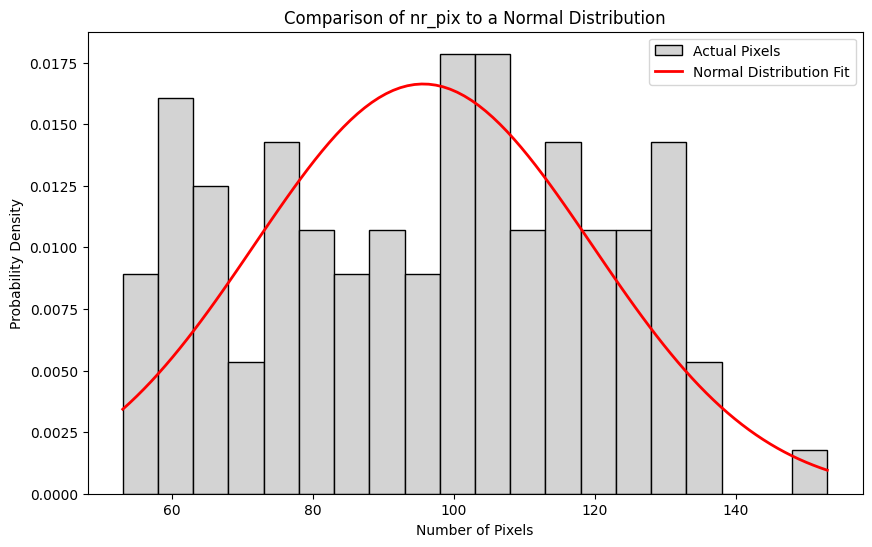

In [19]:
# Task 3.2: Normal fit for nr_pix

pix_data = df['nr_pix']
n_items = len(pix_data)

# Calculating mean and vairance
mu_pix = pix_data.mean()
var_pix = pix_data.var()
std_pix = pix_data.std() # standard deviation

print("Results for nr_pix (Entire Dataset):")
print("Mean:", mu_pix)
print("Variance:", var_pix)

# Creating comparison chart
plt.figure(figsize=(10, 6))

# Plotting the actual histogram first
# Using density=True to match the y-axis with the bell-curve
plt.hist(pix_data, bins=20, density=True, color='lightgray', edgecolor='black', label='Actual Pixels')

# Creating the bell curve line
# np.linspace just creates 100 equally spaced points from min to max to draw a smooth line
x_axis = np.linspace(pix_data.min(), pix_data.max(), 100)
bell_curve = stats.norm.pdf(x_axis, mu_pix, std_pix)

# Plotting the bell curve on top of the actual bars
plt.plot(x_axis, bell_curve, color='red', linewidth=2, label='Normal Distribution Fit')

plt.title('Comparison of nr_pix to a Normal Distribution')
plt.xlabel('Number of Pixels')
plt.ylabel('Probability Density')
plt.legend()

plt.show()

In [20]:
# Task 3.3: 5% Cut-off Value
# Using ppf function to calculate the 95th percentile
cutoff_value = stats.norm.ppf(0.95, loc=mu_pix, scale=np.sqrt(var_pix))

print("The 5% probability cut-off value is:", cutoff_value)

The 5% probability cut-off value is: 135.09497390304614


In [22]:
# Task 3.4: T-Tests
# Finding the parameter that best differentiates the living and non-living objects

# Creating a table
print(f"{'Feature':<15} | {'P-Value'}")
print("-" * 35)

for f in features:
    # The ttest compares the 'Living' group to the 'Non-Living' group, to find which feature shows the most difference
    t_stat, p_val = stats.ttest_ind(living_df[f], non_living_df[f])
    print(f"{f:<15} | {p_val:.10f}")

Feature         | P-Value
-----------------------------------
nr_pix          | 0.0000001552
height          | 0.0026816742
width           | 0.0004534143
aspect_ratio    | 0.7065059180


In [23]:
# Task 3.5: Correlation Matrix

# Calculating the Pearson correlation coefficient between all pairs
corr_matrix = df[['nr_pix', 'height', 'width', 'aspect_ratio']].corr()

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                nr_pix    height     width  aspect_ratio
nr_pix        1.000000  0.250491  0.860760      0.498629
height        0.250491  1.000000  0.001960     -0.631277
width         0.860760  0.001960  1.000000      0.759885
aspect_ratio  0.498629 -0.631277  0.759885      1.000000
